# **Mod_5 Assignment 1**

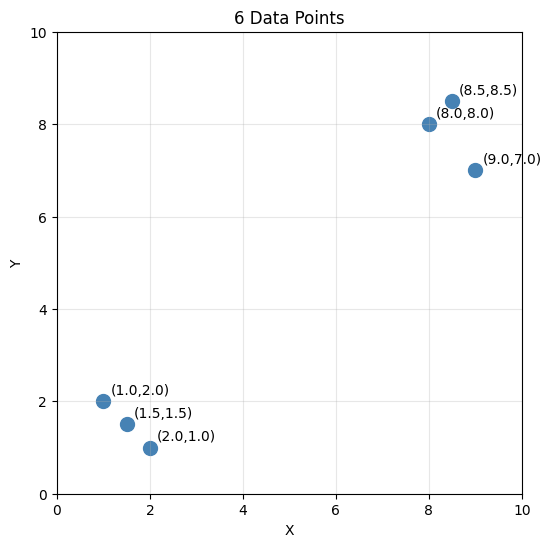

In [1]:
# Task 1 - Step 1 and 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

points = np.array([[1, 2], [2, 1], [1.5, 1.5], [8, 8], [9, 7], [8.5, 8.5]])

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], s=100, color='steelblue')
for x, y in points:
    plt.annotate(f'({x},{y})', (x, y), textcoords="offset points", xytext=(5, 5))
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.title('6 Data Points')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.show()

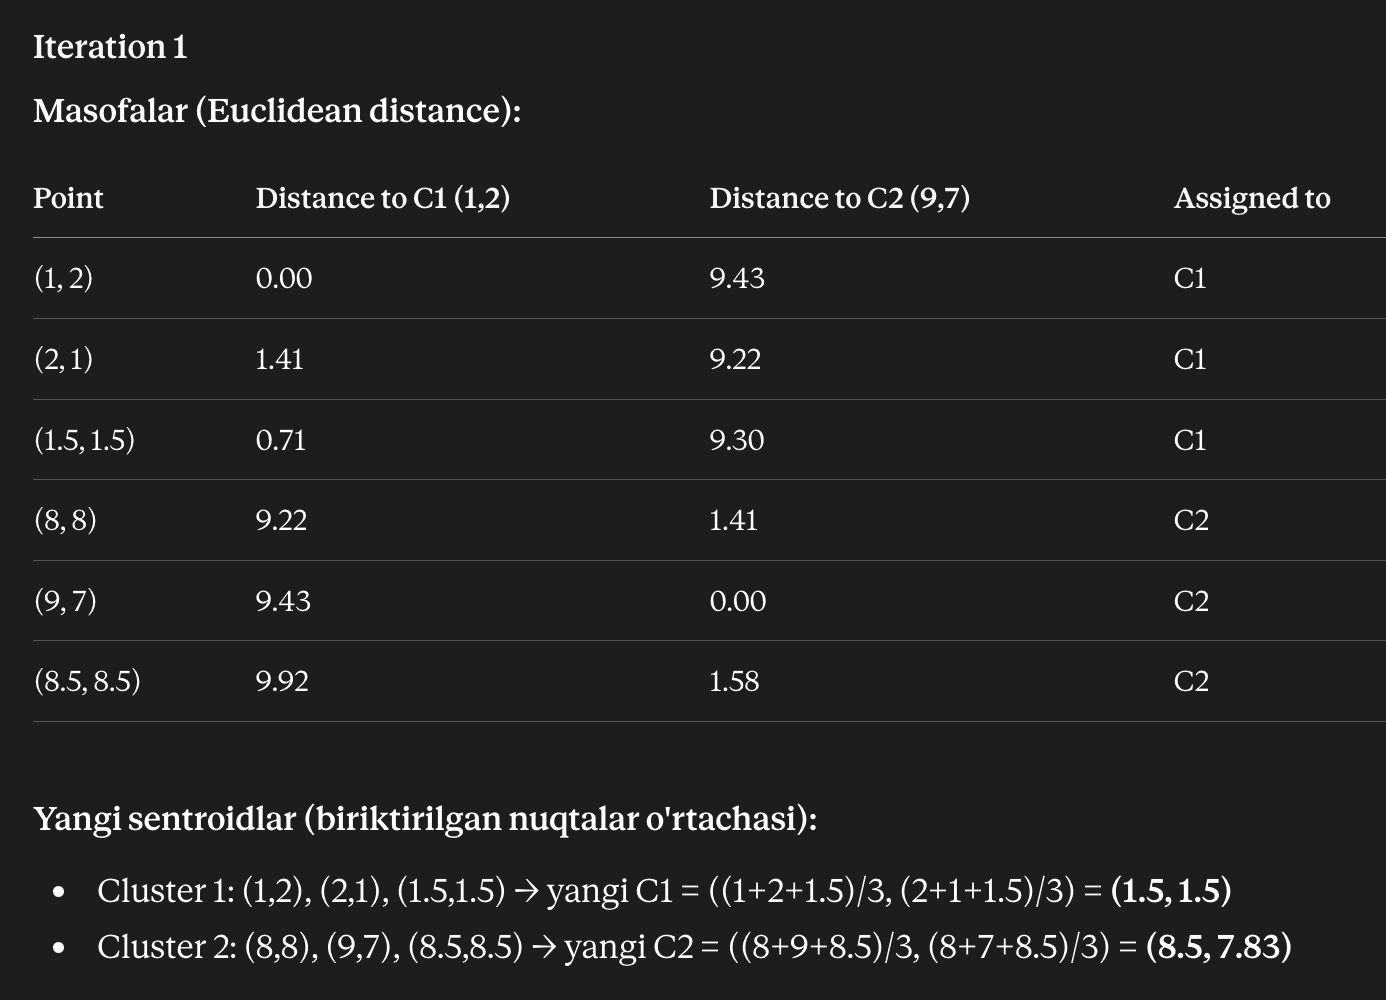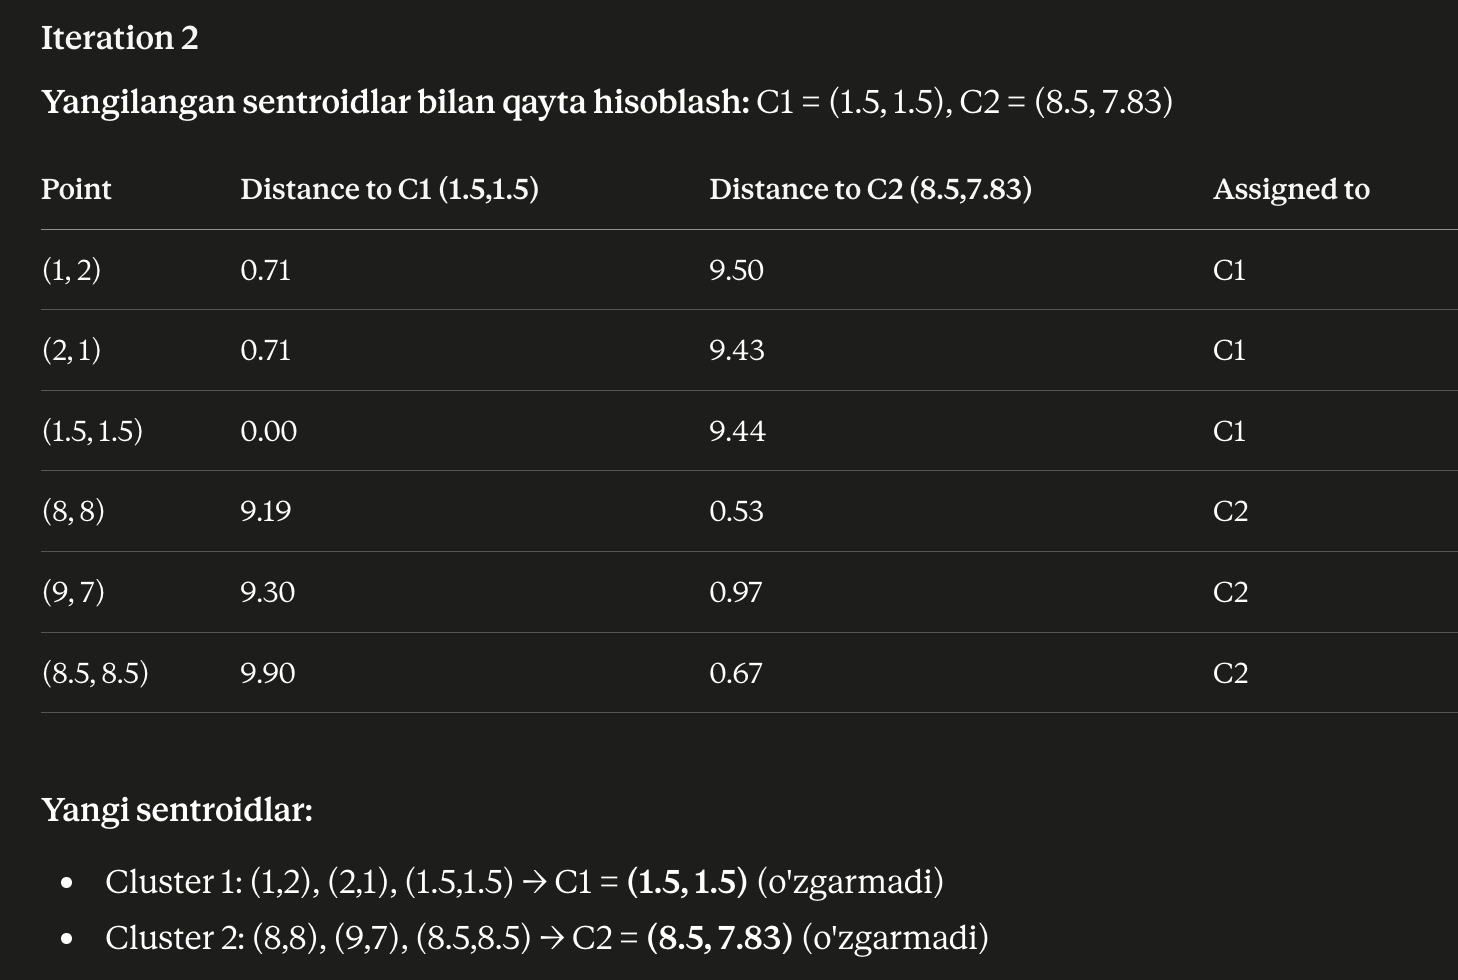

In [2]:
# Task 3 - Step 1, 2 and 3
X = np.array([[1, 2], [2, 1], [1.5, 1.5], [8, 8], [9, 7], [8.5, 8.5]])

kmeans = KMeans(n_clusters=2, init=np.array([[1, 2], [9, 7]]), n_init=1, random_state=42)
labels = kmeans.fit_predict(X)

print('Cluster assignments:', labels)
print('Final centroids:', kmeans.cluster_centers_)

Cluster assignments: [0 0 0 1 1 1]
Final centroids: [[1.5        1.5       ]
 [8.5        7.83333333]]


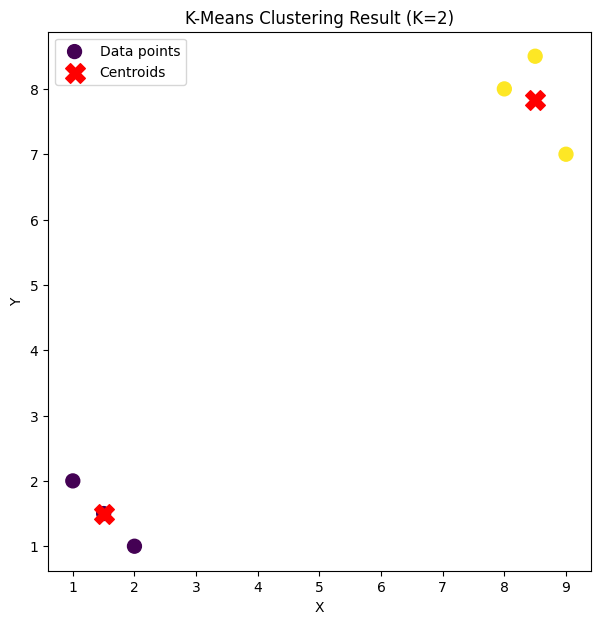

In [3]:
# Task 4 - Step 1, 2 and 3
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=100, label='Data points')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('K-Means Clustering Result (K=2)')
plt.legend()
plt.show()

# **Mod_5 Assignment 2**

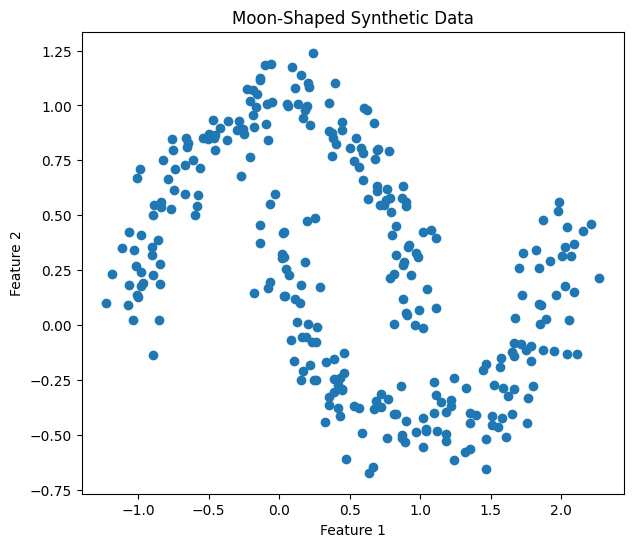

In [4]:
# Task 1 - Step 1 and 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-Shaped Synthetic Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

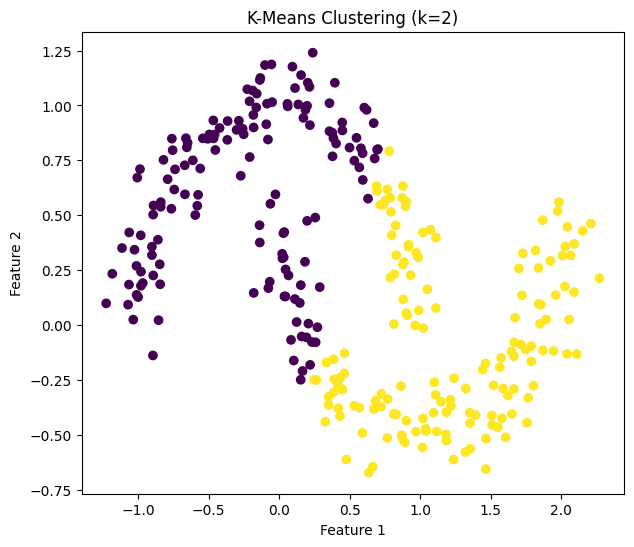

In [5]:
# Task 2 - Step 1 and 2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title('K-Means Clustering (k=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

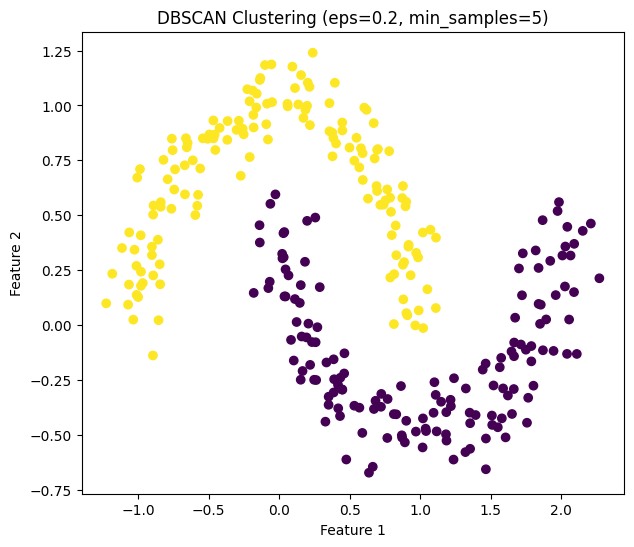

In [6]:
# Task 3 - Step 1 and 2
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X)

plt.figure(figsize=(7, 6))
colors = np.array(['gray' if l == -1 else plt.cm.viridis(l / max(labels_db.max(), 1)) for l in labels_db])
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.title('DBSCAN Clustering (eps=0.2, min_samples=5)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

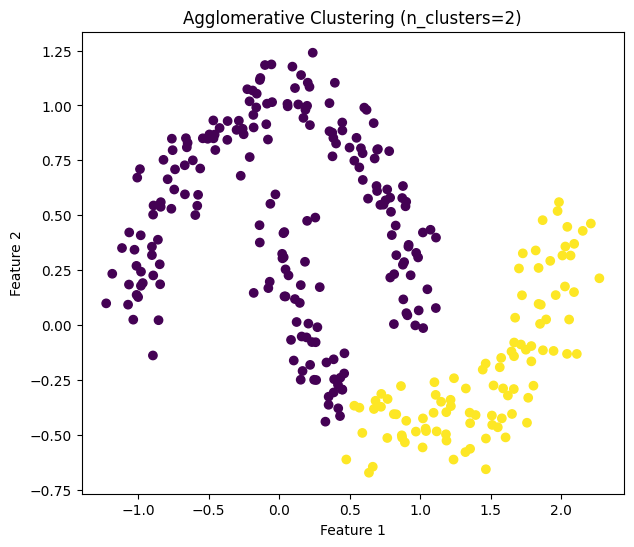

In [7]:
# Task 5 (Bonus)
agg = AgglomerativeClustering(n_clusters=2)
labels_agg = agg.fit_predict(X)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='viridis')
plt.title('Agglomerative Clustering (n_clusters=2)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# **Mod_5 Assignment 3**

In [13]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

url = 'https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv'
df = pd.read_csv(url)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

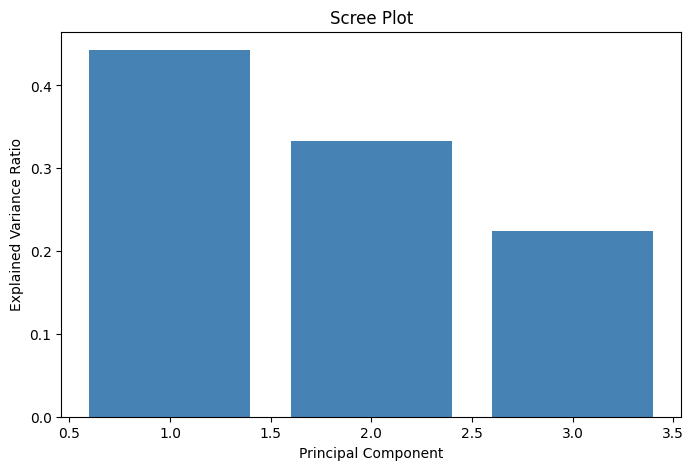

In [14]:
# Task 1 - Step 1, 2 and 3
pca = PCA(n_components=None, random_state=42)
pca.fit(X_scaled)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color='steelblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

In [10]:
# Task 1 - Step 4
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print('Cumulative explained variance:', cumulative_variance.round(4))
print('Components for 90% variance:', np.argmax(cumulative_variance >= 0.90) + 1)
print('Components for 95% variance:', np.argmax(cumulative_variance >= 0.95) + 1)

Cumulative explained variance: [0.4427 0.7757 1.    ]
Components for 90% variance: 3
Components for 95% variance: 3


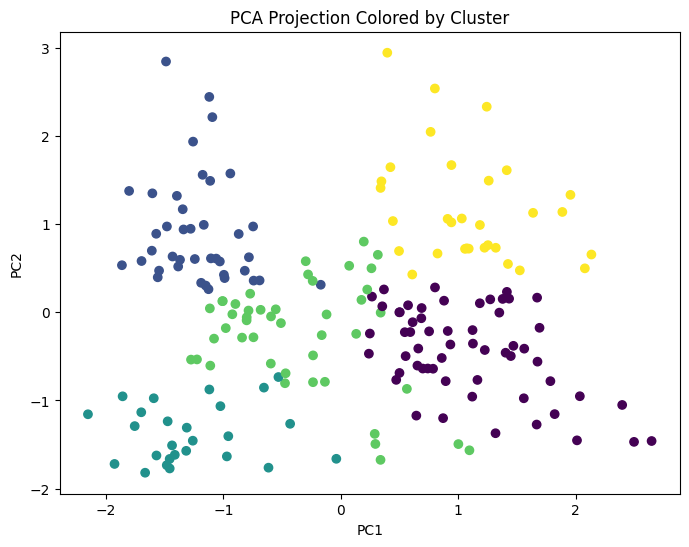

In [11]:
# Task 2 - Step 1 and 2
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection Colored by Cluster')
plt.show()

In [12]:
# Task 3 - Step 1
loadings = pd.DataFrame(pca_2d.components_, columns=features, index=['PC1', 'PC2'])
loadings

,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.706382,-0.048024,-0.706199
PC2,0.030141,0.998832,-0.037775


# **Mod_5 Assignment 4**

In [15]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

url = 'https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv'
df = pd.read_csv(url)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

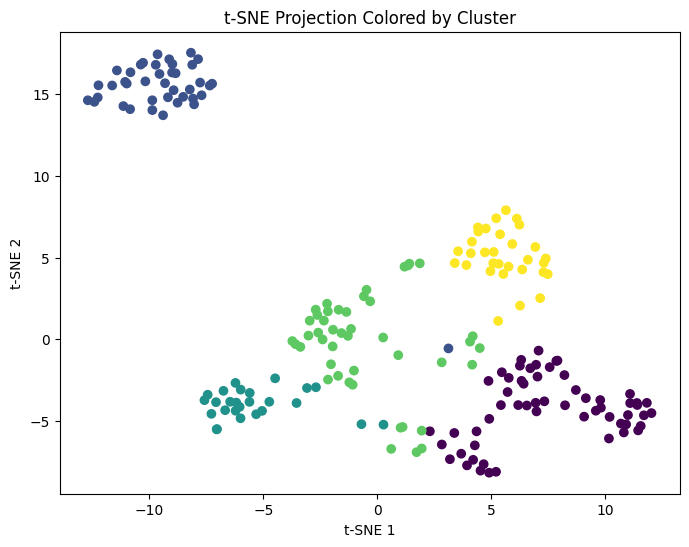

In [16]:
# Task 1 - Step 1 and 2
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Projection Colored by Cluster')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


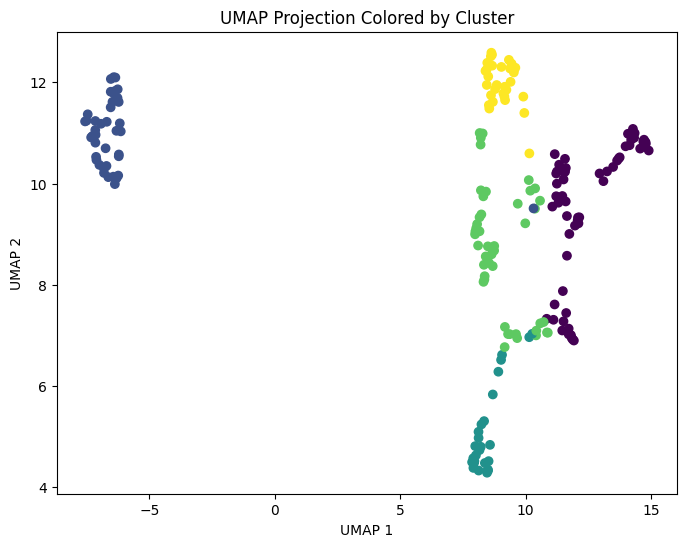

In [17]:
# Task 2 - Step 1, 2 and 3
!pip install umap-learn

import umap
X_umap = umap.UMAP(n_components=2, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap='viridis')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Projection Colored by Cluster')
plt.show()

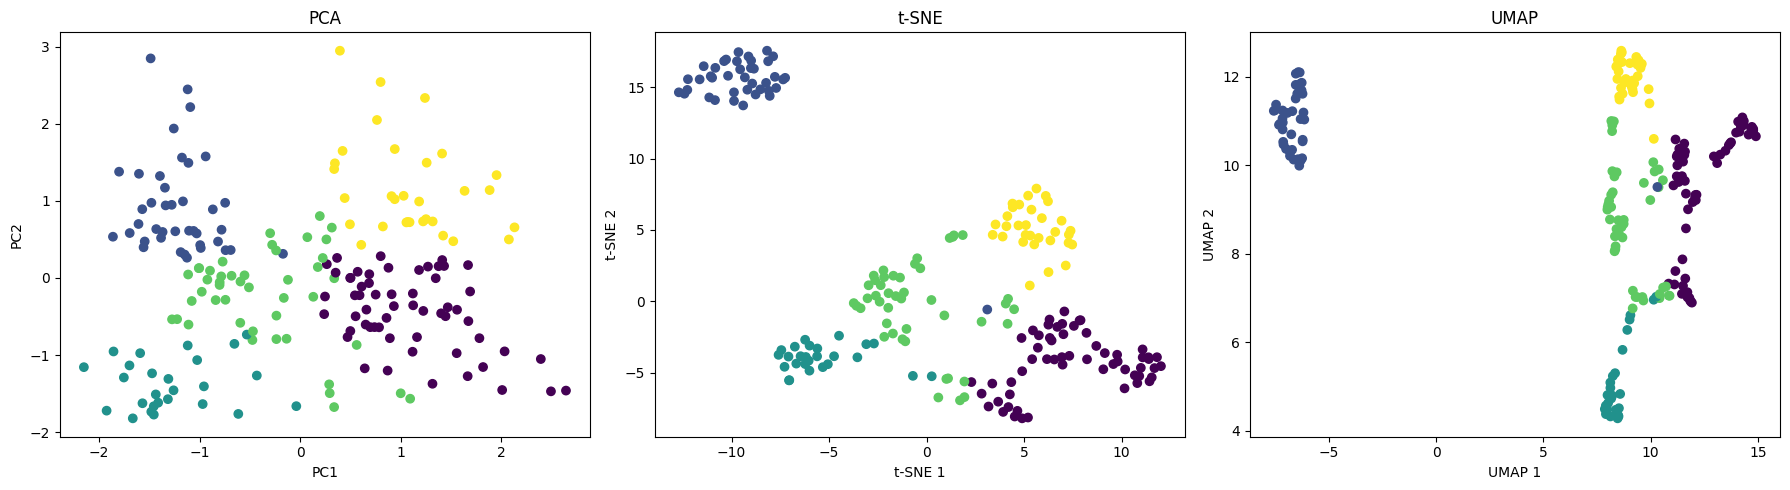

In [18]:
# Task 3 - Step 1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis')
axes[0].set_title('PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='viridis')
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, cmap='viridis')
axes[2].set_title('UMAP')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

# **Mod_5 Assignment 5**

In [19]:
# Activity 3 - Task 1 - Step 1, 2 and 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f'{path}/creditcard.csv')

print(df.shape)
print(df['Class'].value_counts())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [20]:
# Activity 3 - Task 2 - Step 1 and 2
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
# Activity 3 - Task 3 - Step 1
iso_actual = IsolationForest(contamination=0.00173, random_state=42)
iso_actual.fit(X_train)
pred_actual = iso_actual.predict(X_test)
pred_actual = np.where(pred_actual == -1, 1, 0)

In [22]:
# Activity 3 - Task 3 - Step 2
iso_001 = IsolationForest(contamination=0.01, random_state=42)
iso_001.fit(X_train)
pred_001 = iso_001.predict(X_test)
pred_001 = np.where(pred_001 == -1, 1, 0)

iso_0005 = IsolationForest(contamination=0.005, random_state=42)
iso_0005.fit(X_train)
pred_0005 = iso_0005.predict(X_test)
pred_0005 = np.where(pred_0005 == -1, 1, 0)

In [23]:
# Activity 3 - Task 3 - Step 3
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Contamination': [0.00173, 0.01, 0.005],
    'Precision': [precision_score(y_test, pred_actual), precision_score(y_test, pred_001), precision_score(y_test, pred_0005)],
    'Recall': [recall_score(y_test, pred_actual), recall_score(y_test, pred_001), recall_score(y_test, pred_0005)],
    'F1': [f1_score(y_test, pred_actual), f1_score(y_test, pred_001), f1_score(y_test, pred_0005)]
})
comparison

,Contamination,Precision,Recall,F1
0,0.00173,0.308411,0.336735,0.321951
1,0.01000,0.105178,0.663265,0.181564
2,0.00500,0.158416,0.489796,0.239401


In [24]:
# Activity 3 - Task 4 - Step 1
print(classification_report(y_test, pred_actual))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



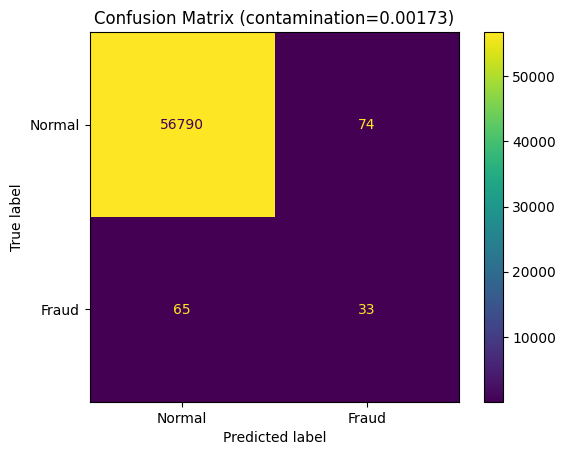

In [25]:
# Activity 3 - Task 4 - Step 2
ConfusionMatrixDisplay.from_predictions(y_test, pred_actual, display_labels=['Normal', 'Fraud'])
plt.title('Confusion Matrix (contamination=0.00173)')
plt.show()

In [26]:
# Activity 3 - Task 5 - Step 1 and 2
scores = iso_actual.decision_function(X_test)
sorted_idx = np.argsort(scores)

top_100_idx = sorted_idx[:100]
top_100_actual = y_test.iloc[top_100_idx]
print('Fraud cases in top 100 most anomalous transactions:', top_100_actual.sum())

Fraud cases in top 100 most anomalous transactions: 32


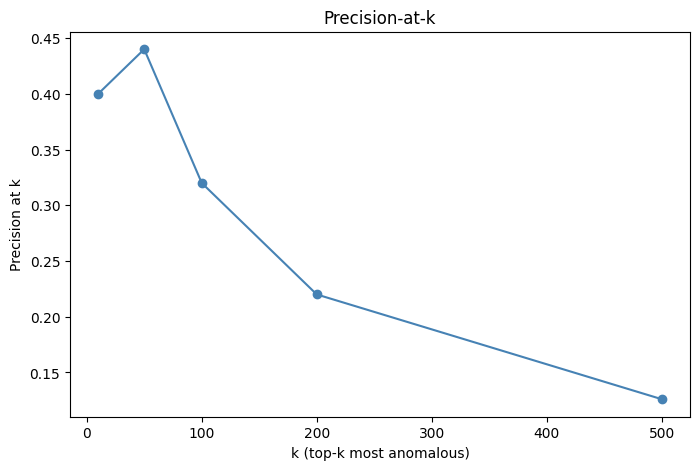

In [27]:
# Activity 3 - Task 5 - Step 3
k_values = [10, 50, 100, 200, 500]
precision_at_k = []
for k in k_values:
    top_k_idx = sorted_idx[:k]
    top_k_actual = y_test.iloc[top_k_idx]
    precision_at_k.append(top_k_actual.sum() / k)

plt.figure(figsize=(8, 5))
plt.plot(k_values, precision_at_k, 'o-', color='steelblue')
plt.xlabel('k (top-k most anomalous)')
plt.ylabel('Precision at k')
plt.title('Precision-at-k')
plt.show()

In [28]:
# Activity 4 - Task 3 - Step 1, 2 and 3
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

transactions = [
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Butter'],
    ['Bread', 'Milk', 'Tea'],
    ['Butter', 'Milk', 'Tea'],
    ['Bread', 'Butter', 'Milk', 'Tea'],
    ['Bread', 'Tea'],
    ['Milk', 'Tea'],
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Milk'],
    ['Butter', 'Tea']
]

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

frequent_items = apriori(df_trans, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_items, metric='confidence', min_threshold=0.5)
rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bread),(Butter),0.7,0.6,0.4,0.571429,0.952381,1.0,-0.02,0.933333,-0.142857,0.444444,-0.071429,0.619048
1,(Butter),(Bread),0.6,0.7,0.4,0.666667,0.952381,1.0,-0.02,0.900000,-0.111111,0.444444,-0.111111,0.619048
2,(Bread),(Milk),0.7,0.7,0.5,0.714286,1.020408,1.0,0.01,1.050000,0.066667,0.555556,0.047619,0.714286
3,(Milk),(Bread),0.7,0.7,0.5,0.714286,1.020408,1.0,0.01,1.050000,0.066667,0.555556,0.047619,0.714286
4,(Tea),(Bread),0.6,0.7,0.3,0.500000,0.714286,1.0,-0.12,0.600000,-0.500000,0.300000,-0.666667,0.464286
5,(Butter),(Milk),0.6,0.7,0.4,0.666667,0.952381,1.0,-0.02,0.900000,-0.111111,0.444444,-0.111111,0.619048
6,(Milk),(Butter),0.7,0.6,0.4,0.571429,0.952381,1.0,-0.02,0.933333,-0.142857,0.444444,-0.071429,0.619048
7,(Tea),(Butter),0.6,0.6,0.3,0.500000,0.833333,1.0,-0.06,0.800000,-0.333333,0.333333,-0.250000,0.500000
8,(Butter),(Tea),0.6,0.6,0.3,0.500000,0.833333,1.0,-0.06,0.800000,-0.333333,0.333333,-0.250000,0.500000
9,(Tea),(Milk),0.6,0.7,0.4,0.666667,0.952381,1.0,-0.02,0.900000,-0.111111,0.444444,-0.111111,0.619048


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
